In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import tensorflow as tf

def UNet():
    # Input Layer: Image (128x128) with 3 RGB channels
    inputs = tf.keras.Input(shape=(128, 128, 3)) # [128, 128, 3]

    # -------- Encoder (Downsampling) --------
    
    # Block 1: Feature Maps increase to 64
    c1 = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    c1 = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(c1) # [128, 128, 64]
    p1 = tf.keras.layers.MaxPooling2D(2)(c1) # [64, 64, 64]

    # Block 2: Spatial size halved, Features doubled
    c2 = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(p1)
    c2 = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(c2) # [64, 64, 128]
    p2 = tf.keras.layers.MaxPooling2D(2)(c2) # [32, 32, 128]

    # Block 3: Deepening features to 256
    c3 = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(p2)
    c3 = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(c3) # [32, 32, 256]
    p3 = tf.keras.layers.MaxPooling2D(2)(c3) # [16, 16, 256]

    # Block 4: Encoder final stage
    c4 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(p3)
    c4 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(c4) # [16, 16, 512]
    p4 = tf.keras.layers.MaxPooling2D(2)(c4) # [8, 8, 512]

    # -------- Bottleneck (The Bridge) --------
    
    # Highest level of abstraction
    c5 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(p4)
    c5 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(c5) # [8, 8, 1024]

    # -------- Decoder (Upsampling & Skip Connections) --------

    # Up 1: Transpose Conv or UpSampling
    u6 = tf.keras.layers.Conv2DTranspose(512, 2, strides=(2, 2), padding='same')(c5) # [16, 16, 512]
    u6 = tf.keras.layers.Concatenate()([u6, c4]) # Skip Connection: [16, 16, 1024]
    c6 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(u6)
    c6 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(c6) # [16, 16, 512]

    # Up 2: Merging with c3
    u7 = tf.keras.layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(c6) # [32, 32, 256]
    u7 = tf.keras.layers.Concatenate()([u7, c3]) # Skip Connection: [32, 32, 512]
    c7 = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(u7)
    c7 = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(c7) # [32, 32, 256]

    # Up 3: Merging with c2
    u8 = tf.keras.layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(c7) # [64, 64, 128]
    u8 = tf.keras.layers.Concatenate()([u8, c2]) # Skip Connection: [64, 64, 256]
    c8 = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(u8)
    c8 = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(c8) # [64, 64, 128]

    # Up 4: Merging with c1 (Full Resolution Restore)
    u9 = tf.keras.layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c8) # [128, 128, 64]
    u9 = tf.keras.layers.Concatenate()([u9, c1]) # Skip Connection: [128, 128, 128]
    c9 = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(u9)
    c9 = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(c9) # [128, 128, 64]

    # -------- Output Layer --------
    # Final pixel-wise classification
    outputs = tf.keras.layers.Conv2D(2, 1, activation='softmax')(c9) # [128, 128, 2]

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

# Initialize and check
model = UNet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_3[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_5[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_7[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8,      │  9,438,208 │ conv2d_9[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_10[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,031,810 (118.38 MB)

 Trainable params: 31,031,810 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Compile Model
model.compile(

optimizer='adam',   # weights update karne ke liye

loss='sparse_categorical_crossentropy',  # segmentation loss

metrics=['accuracy']   # accuracy measure

)

In [7]:
#Dummy Dataset
X_train = np.random.rand(100,128,128,3)

y_train = np.random.randint(0,2,(100,128,128,1))

X_test = np.random.rand(20,128,128,3)

y_test = np.random.randint(0,2,(20,128,128,1))

In [8]:
#Train Model
history = model.fit(

X_train,

y_train,

validation_split=0.2,

epochs=5,

batch_size=8

)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4999 - loss: 0.6939 - val_accuracy: 0.4999 - val_loss: 0.6932
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5005 - loss: 0.6932 - val_accuracy: 0.5007 - val_loss: 0.6931
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5014 - loss: 0.6931 - val_accuracy: 0.4995 - val_loss: 0.6932
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5026 - loss: 0.6931 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5027 - loss: 0.6931 - val_accuracy: 0.5005 - val_loss: 0.6932


In [9]:
#Evaluate Model
loss,accuracy = model.evaluate(X_test,y_test)

print("Test Loss:",loss)

print("Test Accuracy:",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5006 - loss: 0.6932   
Test Loss: 0.693157970905304
Test Accuracy: 0.5005859136581421


In [10]:
#Prediction (Testing)
pred = model.predict(X_test[0:1])

#predicted mask
pred_mask = np.argmax(pred[0],axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


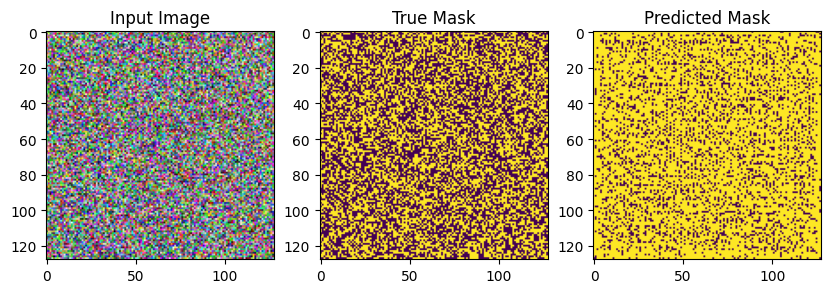

In [11]:
#Visualization
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(X_test[0])

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(y_test[0].squeeze())

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred_mask)

plt.show()